In [21]:
import h5py
import numpy as np

file_name = "dataset.hdf5"

with h5py.File(file_name, 'r') as f:
    print("keys: ", list(f.keys()))
    print("demos: ", list(f['data']))
    print("records: ", list(f['data']['demo_0']))
    print("states: ", list(f['data']['demo_0']['states']['articulation']['robot']))

    actions = f['data']['demo_0']['actions'][:]
    joint_position = f['data']['demo_0']['states']['articulation']['robot']['joint_position'][:]
    joint_velocity = f['data']['demo_0']['states']['articulation']['robot']['joint_velocity'][:]
    torques = f['data']['demo_0']['torques'][:]

keys:  ['data']
demos:  ['demo_0', 'demo_1', 'demo_10', 'demo_100', 'demo_1000', 'demo_1001', 'demo_1002', 'demo_1003', 'demo_1004', 'demo_1005', 'demo_1006', 'demo_1007', 'demo_1008', 'demo_1009', 'demo_101', 'demo_1010', 'demo_1011', 'demo_1012', 'demo_1013', 'demo_1014', 'demo_1015', 'demo_1016', 'demo_1017', 'demo_1018', 'demo_1019', 'demo_102', 'demo_1020', 'demo_1021', 'demo_1022', 'demo_1023', 'demo_1024', 'demo_1025', 'demo_1026', 'demo_1027', 'demo_1028', 'demo_1029', 'demo_103', 'demo_1030', 'demo_1031', 'demo_1032', 'demo_1033', 'demo_1034', 'demo_1035', 'demo_1036', 'demo_1037', 'demo_1038', 'demo_1039', 'demo_104', 'demo_1040', 'demo_1041', 'demo_1042', 'demo_1043', 'demo_1044', 'demo_1045', 'demo_1046', 'demo_1047', 'demo_1048', 'demo_1049', 'demo_105', 'demo_1050', 'demo_1051', 'demo_1052', 'demo_1053', 'demo_1054', 'demo_1055', 'demo_1056', 'demo_1057', 'demo_1058', 'demo_1059', 'demo_106', 'demo_1060', 'demo_1061', 'demo_1062', 'demo_1063', 'demo_1064', 'demo_1065', 'd

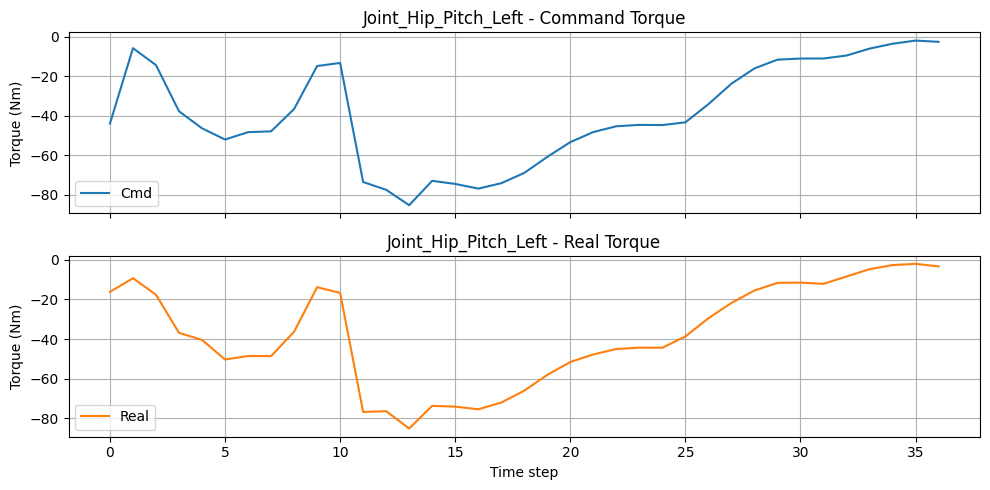

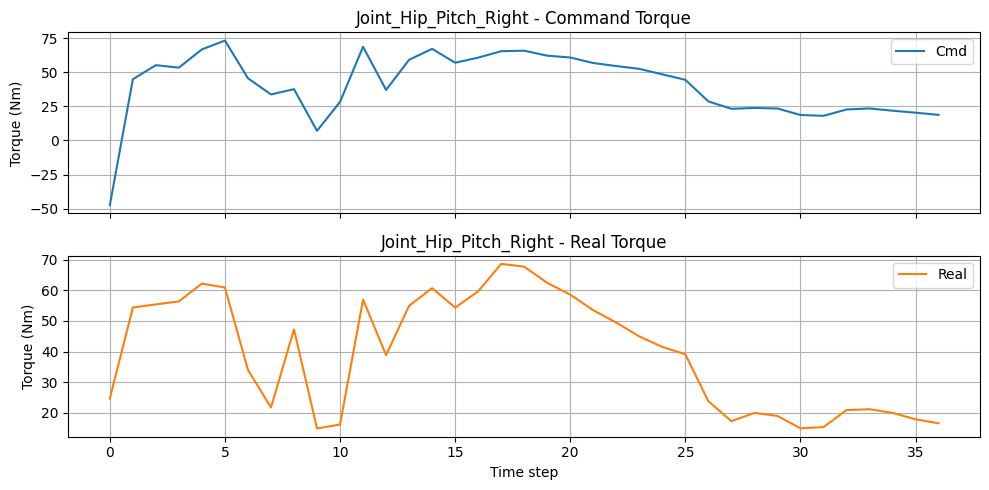

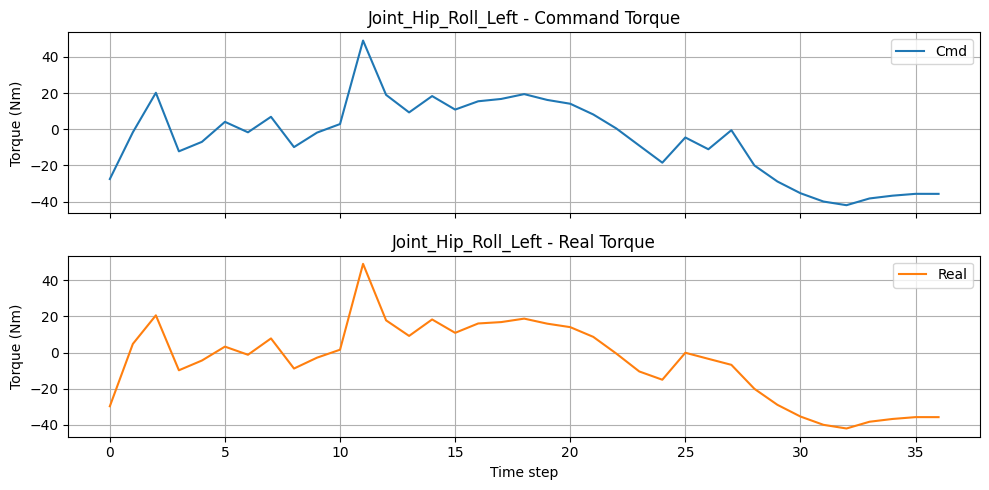

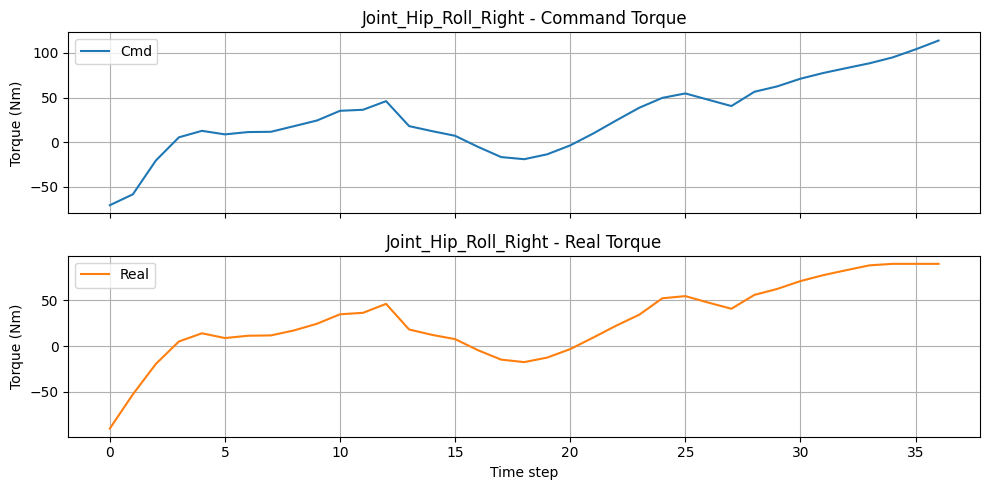

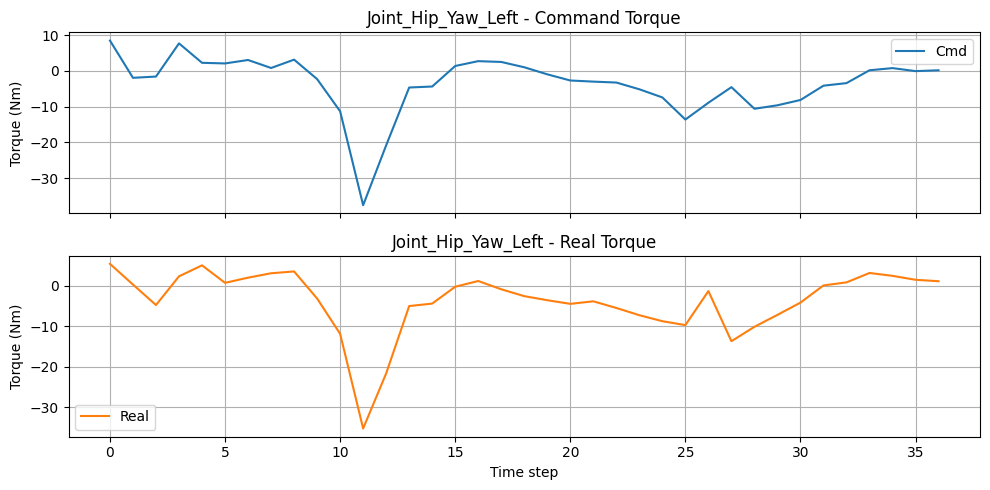

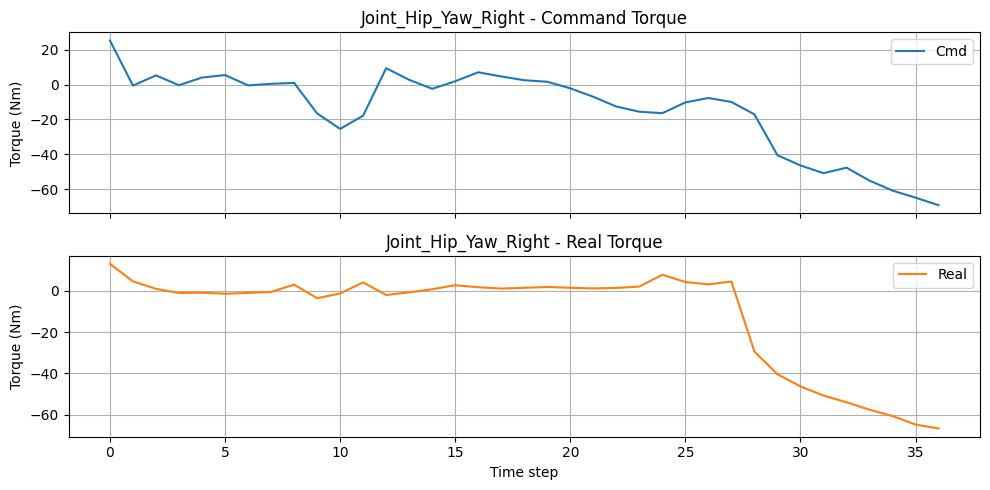

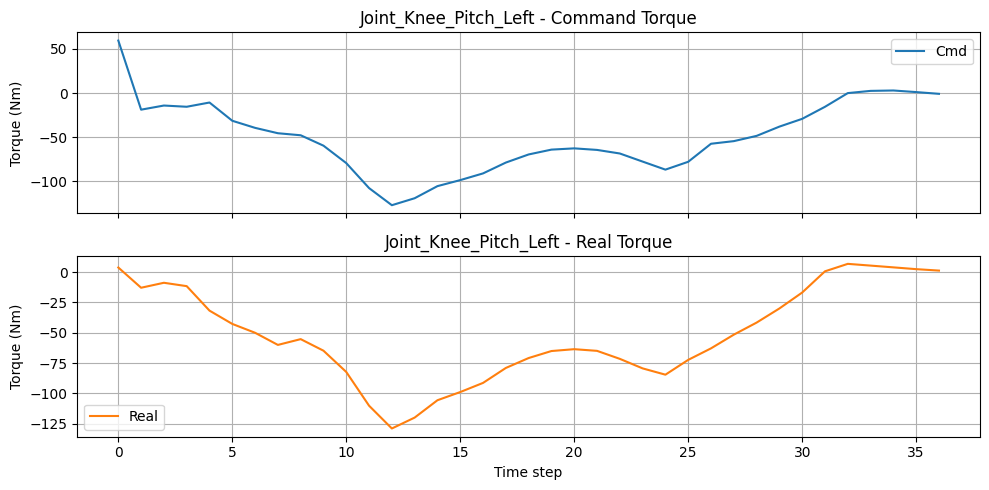

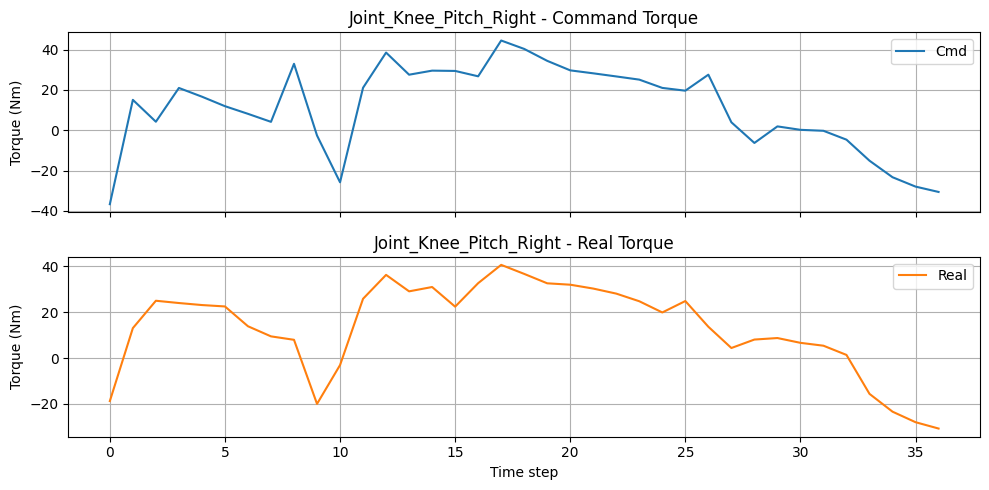

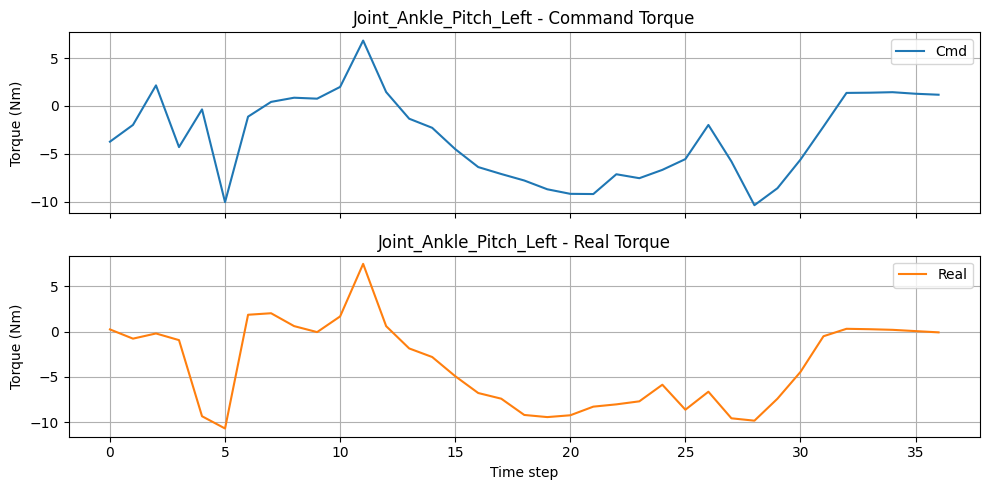

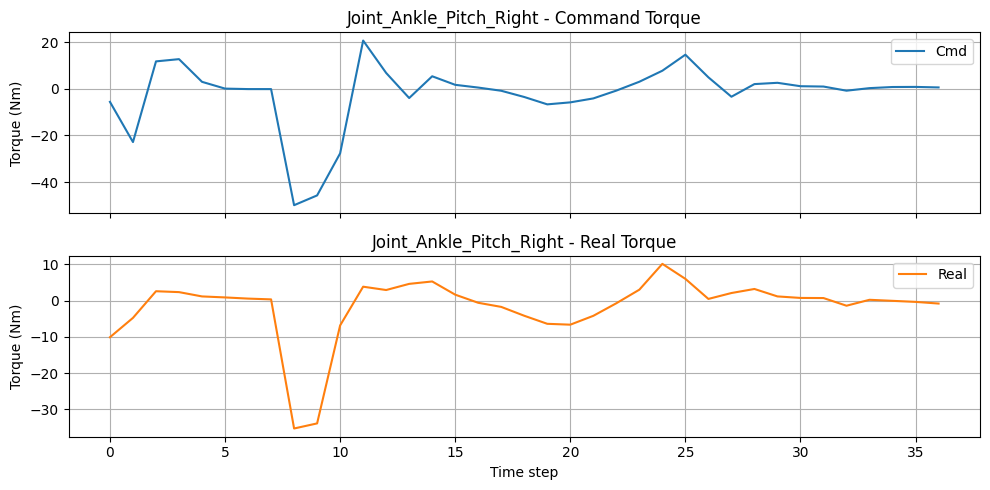

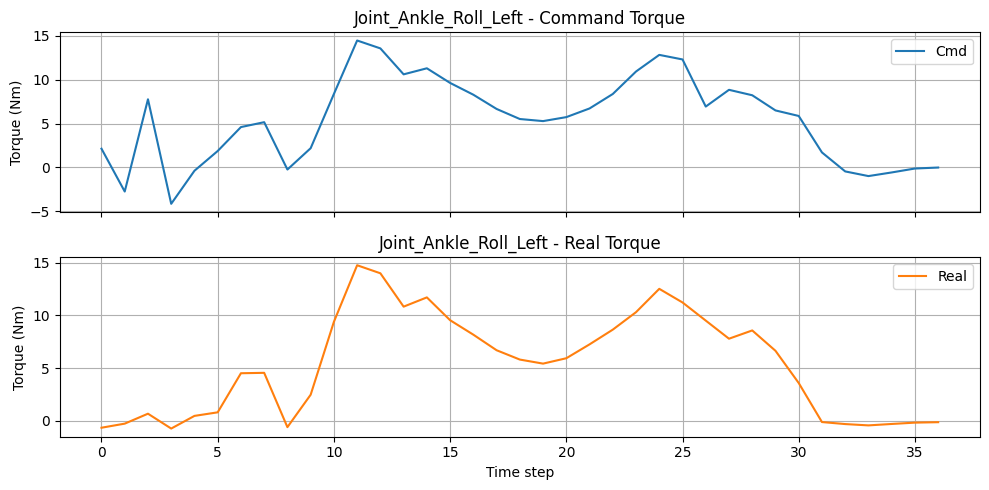

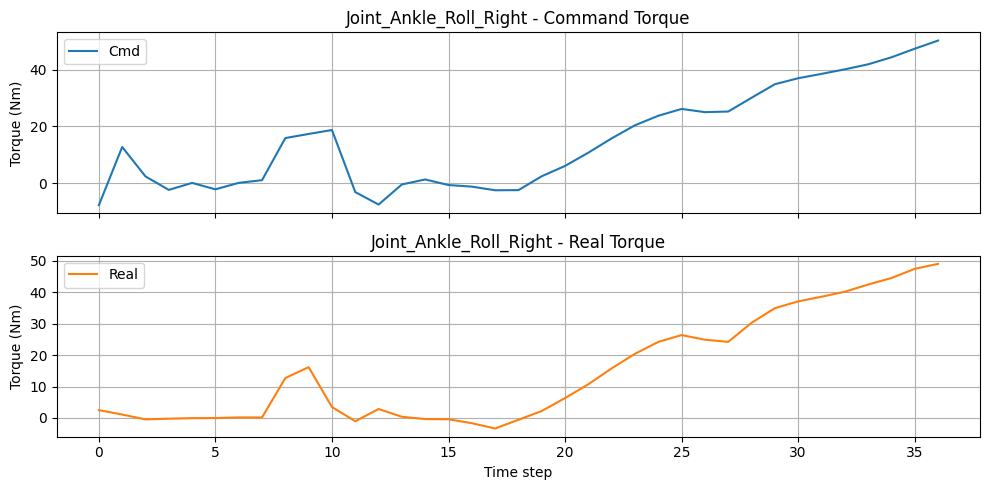

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

joint_names = ['Joint_Hip_Pitch_Left', 'Joint_Hip_Pitch_Right', 'Joint_Hip_Roll_Left', 'Joint_Hip_Roll_Right', 'Joint_Hip_Yaw_Left', 'Joint_Hip_Yaw_Right', 'Joint_Knee_Pitch_Left', 'Joint_Knee_Pitch_Right', 'Joint_Ankle_Pitch_Left', 'Joint_Ankle_Pitch_Right', 'Joint_Ankle_Roll_Left', 'Joint_Ankle_Roll_Right']
joint_default_pos = [-0.2, -0.2, 0, 0, 0, 0, 0.6, 0.6, -0.4, -0.4, 0, 0]
stiffness = [200, 200, 150, 150, 150, 150, 200, 200, 20, 20, 20, 20]
damping = [5, 5, 5, 5, 5, 5, 5, 5, 2, 2, 2, 2]
actions_scale = 0.25

def plot_joint(idx, save_dir=None):
    name      = joint_names[idx]
    kp, kd    = stiffness[idx], damping[idx]
    q0        = joint_default_pos[idx]

    pos   = joint_position[:, idx]
    vel   = joint_velocity[:, idx]
    act   = actions[:, idx]
    cmd_torque = (act * actions_scale - pos + q0) * kp + (-vel) * kd

    real_torque = torques[:, idx]
    t = np.arange(len(real_torque))

    fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    axs[0].plot(t, cmd_torque,  label="Cmd",  color="tab:blue")
    axs[1].plot(t, real_torque, label="Real", color="tab:orange")

    axs[0].set_ylabel("Torque (Nm)")
    axs[1].set_ylabel("Torque (Nm)")
    axs[1].set_xlabel("Time step")

    axs[0].set_title(f"{name} - Command Torque")
    axs[1].set_title(f"{name} - Real Torque")
    for ax in axs:
        ax.grid(True); ax.legend()

    plt.tight_layout()
    plt.show()

# # 批量生成
for i in range(len(joint_names)):
    plot_joint(i, save_dir="torque_plots")   # 去掉 save_dir 参数就会逐张弹窗显示
